## Origin Station Clustering

### Packages

In [20]:
# Data handling
import pandas as pd
import geopandas as gpd
import numpy as np

# Geopandas Dependency
import pyarrow

# Data reading
import requests
from io import BytesIO, StringIO

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import leafmap.foliumap as leafmap

# Feature Engineering
from sklearn.preprocessing import StandardScaler

# Unsupervised Learning
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

### Read the Clean Datasets

In [ ]:
# Read the origin time series file into a DataFrame
url_ts = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/main/Data/Clean/origin_ridership_time_series_CLEAN.csv"
origin = pd.read_csv(StringIO(requests.get(url_ts, verify=False).text))

### Displaying the Dataset

In [9]:
display(origin.head())

,month,day_of_week,hour_of_day,origin_station_complex_id,origin_station_complex_name,origin_latitude,origin_longitude,origin_point,sum_estimated_average_ridership
0,1,Friday,0,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),35.7473
1,1,Friday,1,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),11.4975
2,1,Friday,2,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),10.9980
3,1,Friday,3,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),14.7534
4,1,Friday,4,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),52.0023


### Feature Engineering

#### Recode Day of Week Variable

In [54]:
hour_pivot  = origin.groupby(['origin_station_complex_name', 'hour_of_day'])['sum_estimated_average_ridership'].mean().unstack()
dow_pivot   = origin.groupby(['origin_station_complex_name', 'day_of_week'])['sum_estimated_average_ridership'].mean().unstack()
month_pivot = origin.groupby(['origin_station_complex_name', 'month'])['sum_estimated_average_ridership'].mean().unstack()

station_df  = pd.concat([hour_pivot, dow_pivot, month_pivot], axis=1)
station_df.columns = (
    [f"hour_{h:02d}" for h in range(24)] +
    [f"dow_{d}"      for d in range(7)]  +
    [f"month_{m:02d}" for m in range(1, 13)]
)

station_df

,hour_00,hour_01,hour_02,hour_03,hour_04,hour_05,hour_06,hour_07,hour_08,hour_09,...,month_03,month_04,month_05,month_06,month_07,month_08,month_09,month_10,month_11,month_12
origin_station_complex_name,,,,,,,,,,,,,,,,,,,,,
1 Av (L),226.769186,111.846351,64.253615,37.154957,27.351614,56.752556,223.877729,660.538508,1316.810330,944.104951,...,665.972376,671.063568,730.480807,673.380765,597.192020,644.404501,778.906904,867.580778,812.394774,740.556502
103 St (1),39.052715,11.558332,7.898737,7.096830,15.929852,48.406736,140.075049,450.808646,791.565054,588.484492,...,337.966900,303.469446,325.724330,309.890245,268.075235,277.195624,352.313677,344.714583,356.728211,301.318145
103 St (6),23.195361,12.158142,10.520164,11.328379,26.021038,81.647530,209.854410,487.191511,596.532720,379.434637,...,286.478766,282.228977,283.081675,268.807772,221.919565,227.197331,301.526476,323.397310,320.324373,312.040435
"103 St (C,B)",11.926493,4.350546,3.039625,3.584062,7.623933,23.338936,77.582369,214.009362,331.234680,232.117374,...,121.711599,119.212226,128.946353,133.847206,112.920046,110.337716,131.308093,136.845620,106.965482,123.484630
103 St-Corona Plaza (7),57.216176,42.740326,41.908095,75.053321,307.260507,1080.197112,1692.803336,2293.198961,1833.409098,1209.640380,...,782.701078,778.439690,729.312895,704.555870,614.767946,631.801698,726.182159,737.533891,723.790127,711.957485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Woodhaven Blvd (J,Z)",6.535745,4.316488,3.459004,8.184611,23.295590,65.091530,114.564973,190.797993,162.306299,101.460360,...,36.640898,38.487725,37.743230,41.151410,34.656174,57.713134,117.610237,123.174746,114.212937,105.350176
"Woodhaven Blvd (M,R)",30.367924,12.813948,10.499926,25.201973,86.447762,421.899489,812.212621,1291.631315,1265.310463,793.937374,...,472.990973,472.443639,483.760824,482.565351,428.729343,447.700970,504.750477,530.385974,520.956189,543.607739
Woodlawn (4),27.663074,15.238167,8.208282,15.000014,48.369676,225.352102,373.027965,492.299948,354.859740,206.939614,...,150.239056,154.234124,157.731485,161.239310,136.656738,138.511624,175.010657,172.372645,158.653437,138.542297


#### Scale the Data (Standardize)

In [ ]:
X = np.array(
    station_df.reset_index()
    .drop(columns="origin_station_complex_name")
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

array([[ 1.02683041,  1.28736655,  1.42670097, ...,  0.99084459,
         0.95734692,  0.80344243],
       [-0.1737403 , -0.26304793, -0.28005958, ..., -0.02486379,
         0.03103391, -0.0668228 ],
       [-0.27515855, -0.25377511, -0.20066718, ..., -0.06627425,
        -0.04297053, -0.04557867],
       ...,
       [-0.24658458, -0.2061591 , -0.27068471, ..., -0.35965144,
        -0.37162728, -0.38933143],
       [-0.01547554, -0.06942428, -0.19555365, ...,  0.17142039,
         0.13374608,  0.17223724],
       [-0.41199229, -0.42038094, -0.4698862 , ..., -0.57920533,
        -0.58235697, -0.55221897]])

### Principal Component Analysis (PCA)

In [61]:
# Define PCA object
pca = PCA(n_components = 2)
# Fit to the previously scaled X feature array
X_pca = pca.fit_transform(X_scaled)

# Create dataframe with first two principal components (for plotting)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# Concatenate the station labels to each observation
pca_df["station"] = station_df.reset_index()["origin_station_complex_name"]

# Sort by PC1 descending to find extreme outlier stations
pca_df.sort_values(by="PC1", ascending=False).head(10)


,PC1,PC2,station
399,67.613375,6.138826,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)"
282,43.456091,-2.216307,"Grand Central-42 St (S,4,5,6,7)"
85,33.396352,-3.860037,"34 St-Herald Sq (B,D,F,M,N,Q,R,W)"
26,30.179508,-5.761502,"14 St-Union Sq (L,N,Q,R,W,4,5,6)"
88,23.402935,1.157492,"34 St-Penn Station (A,C,E)"
276,22.942293,-2.266203,"Fulton St (A,C,J,Z,2,3,4,5)"
87,20.757955,2.808288,"34 St-Penn Station (1,2,3)"
111,20.689347,-4.025151,"59 St-Columbus Circle (A,B,C,D,1)"
126,20.097537,10.773083,"74-Broadway (7)/Jackson Hts-Roosevelt Av (E,F,..."
263,18.320336,9.126264,Flushing-Main St (7)


<Axes: xlabel='PC1', ylabel='PC2'>

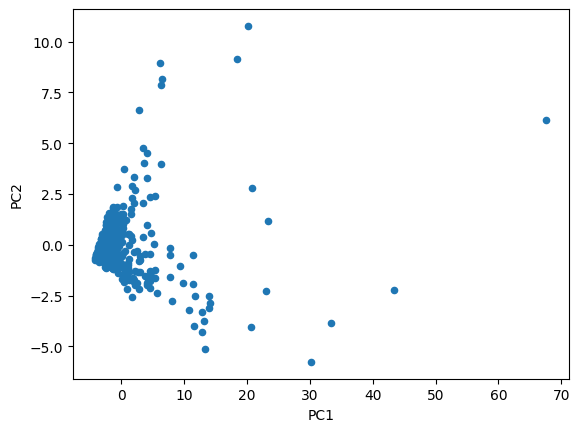

In [62]:
# Scatterplot of PC1 and PC2 (Not really any patterns)
pca_df.plot(x='PC1', y = "PC2", kind='scatter')